In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
df = pd.read_csv("E-CURD-149.condensed-sdrf.tsv", sep="\t", on_bad_lines='skip', header=None)
df.columns = ["Experiment", "Unused", "Sample_ID", "Type", "Attribute", "Value"]
df = df[df["Type"] == "characteristic"]
df_wide = df.pivot_table(index="Sample_ID", columns="Attribute", values="Value", aggfunc='first').reset_index()
df_wide.head()
# This file contains metadata for each sample, such as the child's age, sample ID, and cohort.
# It is used to link each sample with its clinical or demographic information during analysis.

Attribute,Sample_ID,age,cohort,individual
0,ERR11658897,51 month,PERFORM,individual 625
1,ERR11658898,61 month,PERFORM,individual 579
2,ERR11658899,89 month,PERFORM,individual 615
3,ERR11658900,87 month,PERFORM,individual 613
4,ERR11658901,49 month,PERFORM,individual 617


In [4]:
df_genes = pd.read_csv("E-CURD-149-analytics.tsv", sep="\t")
df_genes.head()
#Genes whose expression changed between different groups of children.
#Is this change large enough to be statistically significant (p-value)?
#The direction of the change (increased or decreased) is shown using log2foldchange.

,Gene ID,Gene Name,g3_g1.p-value,g3_g1.log2foldchange,g3_g2.p-value,g3_g2.log2foldchange
0,ENSG00000000003,TSPAN6,0.635570,-0.7,0.055791,-1.3
1,ENSG00000000005,TNMD,NaN,-2.1,NaN,-0.7
2,ENSG00000000419,DPM1,0.365973,0.3,0.164996,0.2
3,ENSG00000000457,SCYL3,0.609381,0.2,0.092423,0.3
4,ENSG00000000460,FIRRM,0.973755,0.0,0.324863,0.2


In [5]:
df_counts = pd.read_csv("E-CURD-149-raw-counts.tsv", sep="\t", index_col=0)
df_counts.head()
#"Each gene was expressed how often (read how many times) in each sample?
#Each row = a gene.
#Each column from the third onwards = a sample (patient or specific condition).
#The number = the number of times the gene is expressed (meaning how active it is in the cell).

,Gene Name,ERR11658905,ERR11658920,ERR11658906,ERR11658917,ERR11658912,ERR11658914,ERR11658913,ERR11658911,ERR11658935,...,ERR11658919,ERR11658918,ERR11658902,ERR11658900,ERR11658899,ERR11658901,ERR11658916,ERR11658915,ERR11658897,ERR11658934
Gene ID,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,TSPAN6,0,10,16,14,4,19,2,21,2,...,4,2,9,1,5,6,0,0,6,1
ENSG00000000005,TNMD,1,2,2,0,0,1,0,0,2,...,0,0,0,0,0,0,0,0,0,0
ENSG00000000419,DPM1,854,853,1020,1166,748,1184,1119,1210,844,...,753,459,613,576,575,532,410,430,660,1056
ENSG00000000457,SCYL3,1179,694,1127,1560,1152,1284,1075,1257,1000,...,740,531,710,591,605,508,435,449,638,961
ENSG00000000460,FIRRM,365,302,375,538,321,523,447,489,300,...,263,207,264,181,202,145,110,161,229,328


In [6]:
num_samples = df_wide.shape[0]
print("Number of samples:", num_samples)

Number of samples: 46


In [7]:
num_individuals = df_wide["individual"].nunique()
print("Number of unique individuals:", num_individuals)

Number of unique individuals: 46


In [8]:
df_wide["age_numeric"] = df_wide["age"].str.extract(r"(\d+)").astype(float)
print("Minimum age:", df_wide["age_numeric"].min())
print("Maximum age:", df_wide["age_numeric"].max())
print("Average age:", df_wide["age_numeric"].mean())

Minimum age: 0.0
Maximum age: 207.0
Average age: 113.19565217391305


In [9]:
print("Number of unique cohorts:", df_wide["cohort"].nunique())
print("Sample count per cohort:")
print(df_wide["cohort"].value_counts())

Number of unique cohorts: 1
Sample count per cohort:
cohort
PERFORM    46
Name: count, dtype: int64


In [10]:
print(df_wide["age_numeric"].describe())

count     46.000000
mean     113.195652
std       59.458153
min        0.000000
25%       61.250000
50%      133.500000
75%      161.250000
max      207.000000
Name: age_numeric, dtype: float64


In [11]:
individual_counts = df_wide["individual"].value_counts()
print("Individuals with multiple samples:")
print(individual_counts[individual_counts > 1])

Individuals with multiple samples:
Series([], Name: count, dtype: int64)


In [12]:
df_wide.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46 entries, 0 to 45
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Sample_ID    46 non-null     object 
 1   age          46 non-null     object 
 2   cohort       46 non-null     object 
 3   individual   46 non-null     object 
 4   age_numeric  46 non-null     float64
dtypes: float64(1), object(4)
memory usage: 1.9+ KB


In [13]:
print(df_wide.isnull().sum())

Attribute
Sample_ID      0
age            0
cohort         0
individual     0
age_numeric    0
dtype: int64


In [14]:
df_clean = df_wide.dropna(subset=["age_numeric"])
Q1 = df_clean["age_numeric"].quantile(0.25)
Q3 = df_clean["age_numeric"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_clean[(df_clean["age_numeric"] < lower_bound) | (df_clean["age_numeric"] > upper_bound)]
print("Outliers:")
print(outliers)

# Remove outliers if desired
df_no_outliers = df_clean[(df_clean["age_numeric"] >= lower_bound) & (df_clean["age_numeric"] <= upper_bound)]
outlier_count = outliers.shape[0]
total_count = df_clean.shape[0]
outlier_percentage = (outlier_count / total_count) * 100

print(f"Outliers count: {outlier_count}")
print(f"Outliers percentage: {outlier_percentage:.2f}%")

Outliers:
Empty DataFrame
Columns: [Sample_ID, age, cohort, individual, age_numeric]
Index: []
Outliers count: 0
Outliers percentage: 0.00%


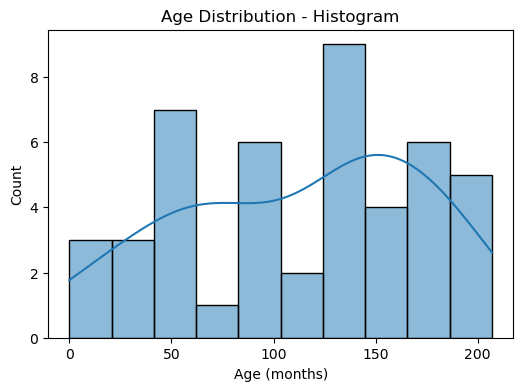

In [15]:
plt.figure(figsize=(6, 4))
sns.histplot(df_wide["age_numeric"], bins=10, kde=True)
plt.title("Age Distribution - Histogram")
plt.xlabel("Age (months)")
plt.ylabel("Count")
plt.show()

In [16]:
df_genes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61860 entries, 0 to 61859
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Gene ID               61860 non-null  object 
 1   Gene Name             42277 non-null  object 
 2   g3_g1.p-value         30034 non-null  float64
 3   g3_g1.log2foldchange  61860 non-null  float64
 4   g3_g2.p-value         35603 non-null  float64
 5   g3_g2.log2foldchange  61860 non-null  float64
dtypes: float64(4), object(2)
memory usage: 2.8+ MB


In [17]:
df_genes.describe()

,g3_g1.p-value,g3_g1.log2foldchange,g3_g2.p-value,g3_g2.log2foldchange
count,3.003400e+04,61860.000000,3.560300e+04,61860.000000
mean,5.040603e-01,-0.081565,3.445542e-01,0.102650
std,2.860188e-01,1.004782,3.147526e-01,0.845358
min,8.380419e-08,-23.100000,1.359739e-16,-8.700000
25%,2.552506e-01,-0.500000,5.596064e-02,-0.300000
50%,4.912547e-01,0.000000,2.470419e-01,0.000000
75%,7.573446e-01,0.200000,6.056848e-01,0.500000
max,1.000000e+00,10.000000,9.999118e-01,9.100000


In [18]:
print("Missing values per column:")
print(df_genes.isnull().sum())

Missing values per column:
Gene ID                     0
Gene Name               19583
g3_g1.p-value           31826
g3_g1.log2foldchange        0
g3_g2.p-value           26257
g3_g2.log2foldchange        0
dtype: int64


In [19]:
from sklearn.impute import KNNImputer
columns_to_impute = ["g3_g1.p-value", "g3_g2.p-value"]
df_knn = df_genes[columns_to_impute].copy()
df_knn["g3_g1.log2foldchange"] = df_genes["g3_g1.log2foldchange"]
df_knn["g3_g2.log2foldchange"] = df_genes["g3_g2.log2foldchange"]
imputer = KNNImputer(n_neighbors=5)
imputed_array = imputer.fit_transform(df_knn)
df_imputed = pd.DataFrame(imputed_array, columns=df_knn.columns)
df_genes["g3_g1.p-value"] = df_imputed["g3_g1.p-value"]
df_genes["g3_g2.p-value"] = df_imputed["g3_g2.p-value"]

In [20]:
print(df_genes.isnull().sum())

Gene ID                     0
Gene Name               19583
g3_g1.p-value               0
g3_g1.log2foldchange        0
g3_g2.p-value               0
g3_g2.log2foldchange        0
dtype: int64


In [21]:
df_genes["Gene Name"] = df_genes["Gene Name"].fillna("Unknown")

In [22]:
df_genes.describe()

,g3_g1.p-value,g3_g1.log2foldchange,g3_g2.p-value,g3_g2.log2foldchange
count,6.186000e+04,61860.000000,6.186000e+04,61860.000000
mean,6.281733e-01,-0.081565,4.754677e-01,0.102650
std,3.239888e-01,1.004782,3.612054e-01,0.845358
min,8.380419e-08,-23.100000,1.359739e-16,-8.700000
25%,3.246599e-01,-0.500000,1.275103e-01,-0.300000
50%,6.810875e-01,0.000000,3.869902e-01,0.000000
75%,9.660934e-01,0.200000,9.365656e-01,0.500000
max,1.000000e+00,10.000000,9.999118e-01,9.100000


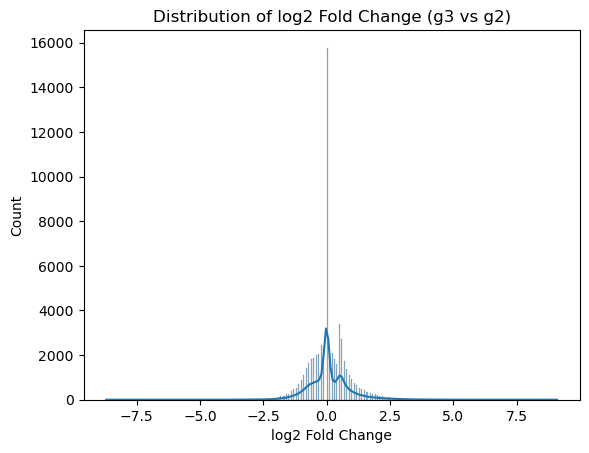

In [23]:
sns.histplot(df_genes["g3_g2.log2foldchange"], kde=True)
plt.title("Distribution of log2 Fold Change (g3 vs g2)")
plt.xlabel("log2 Fold Change")
plt.ylabel("Count")
plt.show()

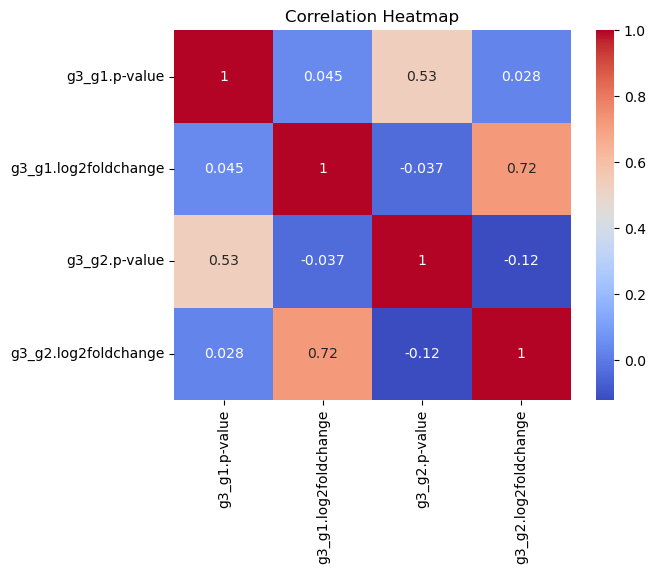

In [24]:
sns.heatmap(df_genes.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [25]:
  # Thresholds
up_threshold = 2
down_threshold = -2
def classify_gene(fc):
    if fc >= up_threshold:
        return "Upregulated"
    elif fc <= down_threshold:
        return "Downregulated"
    else:
        return "Normal"
df_genes["g3_g1_class"] = df_genes["g3_g1.log2foldchange"].apply(classify_gene)
df_genes["g3_g2_class"] = df_genes["g3_g2.log2foldchange"].apply(classify_gene)
g1_counts = df_genes["g3_g1_class"].value_counts()
g2_counts = df_genes["g3_g2_class"].value_counts()
print(" g3 vs g1 classification:")
print(g1_counts)
print("\n g3 vs g2 classification:")
print(g2_counts)
important_genes_g1 = df_genes[df_genes["g3_g1_class"] != "Normal"]
important_genes_g2 = df_genes[df_genes["g3_g2_class"] != "Normal"]

 g3 vs g1 classification:
g3_g1_class
Normal           57666
Downregulated     2343
Upregulated       1851
Name: count, dtype: int64

 g3 vs g2 classification:
g3_g2_class
Normal           59486
Upregulated       1841
Downregulated      533
Name: count, dtype: int64


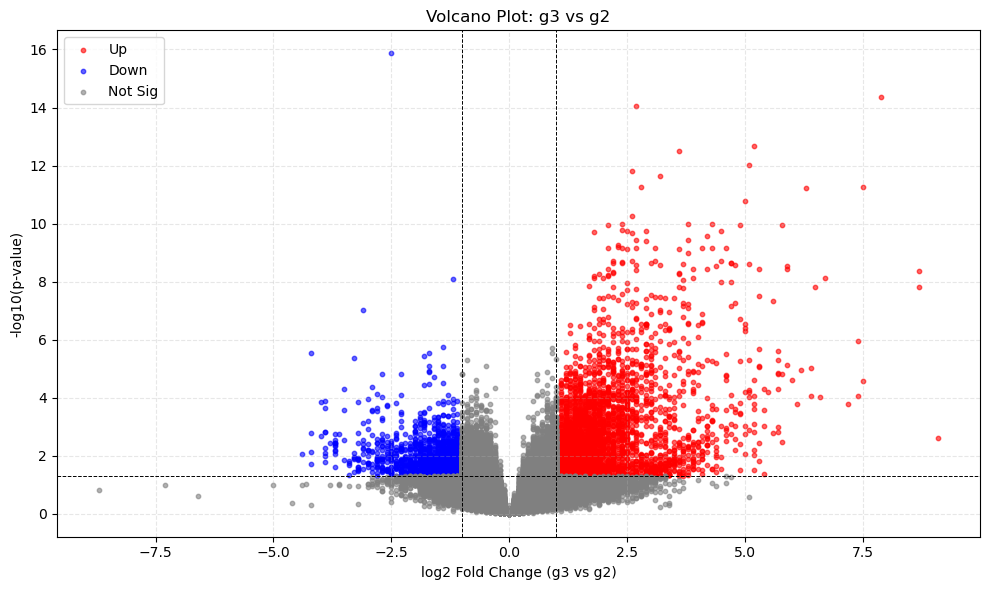

In [26]:
import matplotlib.pyplot as plt
import numpy as np
df_volcano = df_genes.copy()
df_volcano["g3_g2.p-value"] = df_volcano["g3_g2.p-value"].replace(0, 1e-300)
df_volcano["-log10(p-value)"] = -np.log10(df_volcano["g3_g2.p-value"])
def volcano_label(row):
    if row["g3_g2.log2foldchange"] > 1 and row["g3_g2.p-value"] < 0.05:
        return "Up"
    elif row["g3_g2.log2foldchange"] < -1 and row["g3_g2.p-value"] < 0.05:
        return "Down"
    else:
        return "Not Sig"
df_volcano["Significance"] = df_volcano.apply(volcano_label, axis=1)
plt.figure(figsize=(10, 6))
colors = {'Up': 'red', 'Down': 'blue', 'Not Sig': 'gray'}
for label in ['Up', 'Down', 'Not Sig']:
    subset = df_volcano[df_volcano["Significance"] == label]
    plt.scatter(subset["g3_g2.log2foldchange"],subset["-log10(p-value)"],c=colors[label],label=label,alpha=0.6,s=10)
plt.axhline(-np.log10(0.05), color='black', linestyle='--', linewidth=0.7)
plt.axvline(1, color='black', linestyle='--', linewidth=0.7)
plt.axvline(-1, color='black', linestyle='--', linewidth=0.7)
plt.xlabel("log2 Fold Change (g3 vs g2)")
plt.ylabel("-log10(p-value)")
plt.title("Volcano Plot: g3 vs g2")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

In [27]:
total_genes = df_genes.shape[0]
print("Total genes:", total_genes)

Total genes: 61860


In [28]:
significant_g1 = df_genes[df_genes["g3_g1.p-value"] < 0.05]
significant_g2 = df_genes[df_genes["g3_g2.p-value"] < 0.05]

print("Significant genes (g3 vs g1):", significant_g1.shape[0])
print("Significant genes (g3 vs g2):", significant_g2.shape[0])

Significant genes (g3 vs g1): 1077
Significant genes (g3 vs g2): 9320


In [52]:
significant_g1 = df_genes[df_genes["g3_g1.p-value"] < 0.05]
significant_g2 = df_genes[df_genes["g3_g2.p-value"] < 0.05]
common_genes = set(significant_g1["Gene ID"]).intersection(significant_g2["Gene ID"])
common_genes_df = df_genes[df_genes["Gene ID"].isin(common_genes)]
common_genes_df.head()


,Gene ID,Gene Name,g3_g1.p-value,g3_g1.log2foldchange,g3_g2.p-value,g3_g2.log2foldchange,g3_g1_class,g3_g2_class
26,ENSG00000002745,WNT16,0.046737,-1.8,2.326129e-02,-1.0,Normal,Normal
91,ENSG00000005302,MSL3,0.037814,1.5,3.474129e-05,1.5,Normal,Normal
112,ENSG00000005961,ITGA2B,0.033410,2.3,1.956568e-09,3.1,Upregulated,Upregulated
219,ENSG00000008438,PGLYRP1,0.047197,1.9,8.288194e-05,1.8,Normal,Normal
242,ENSG00000009950,MLXIPL,0.038856,6.1,4.728360e-02,2.9,Upregulated,Upregulated


In [53]:
filtered_common = common_genes_df[
    (common_genes_df["g3_g1.p-value"] < 0.05) &
    (common_genes_df["g3_g2.p-value"] < 0.05) &
    ((common_genes_df["g3_g1_class"] != "Normal") | (common_genes_df["g3_g2_class"] != "Normal"))
]

print("Filtered genes:", filtered_common.shape[0])
filtered_common.head()


Filtered genes: 468


,Gene ID,Gene Name,g3_g1.p-value,g3_g1.log2foldchange,g3_g2.p-value,g3_g2.log2foldchange,g3_g1_class,g3_g2_class
112,ENSG00000005961,ITGA2B,0.033410,2.3,1.956568e-09,3.1,Upregulated,Upregulated
242,ENSG00000009950,MLXIPL,0.038856,6.1,4.728360e-02,2.9,Upregulated,Upregulated
315,ENSG00000012223,LTF,0.019152,4.6,5.280114e-06,4.3,Upregulated,Upregulated
394,ENSG00000019991,HGF,0.046737,3.3,5.194199e-04,2.9,Upregulated,Upregulated
405,ENSG00000021355,SERPINB1,0.013223,2.9,1.342450e-05,2.6,Upregulated,Upregulated


In [54]:
filtered_common["g3_g1_class"].value_counts()


g3_g1_class
Upregulated      362
Downregulated     95
Normal            11
Name: count, dtype: int64

In [30]:
common_genes = set(significant_g1["Gene ID"]) & set(significant_g2["Gene ID"])
print("Common significant genes:", len(common_genes))

Common significant genes: 806


In [31]:
important_g1 = df_genes[
    (df_genes["g3_g1.p-value"] < 0.05) & 
    (abs(df_genes["g3_g1.log2foldchange"]) > 1)
]

important_g2 = df_genes[
    (df_genes["g3_g2.p-value"] < 0.05) & 
    (abs(df_genes["g3_g2.log2foldchange"]) > 1)
]

print("Important genes (g3 vs g1):", important_g1.shape[0])
print("Important genes (g3 vs g2):", important_g2.shape[0])

Important genes (g3 vs g1): 951
Important genes (g3 vs g2): 4871


In [32]:
print("Important % (g3 vs g1):", round((important_g1.shape[0] / total_genes) * 100, 2), "%")
print("Important % (g3 vs g2):", round((important_g2.shape[0] / total_genes) * 100, 2), "%")

Important % (g3 vs g1): 1.54 %
Important % (g3 vs g2): 7.87 %


In [65]:
upregulated_g1 = df_genes[(df_genes["g3_g1_class"] == "Upregulated")]
downregulated_g1 = df_genes[(df_genes["g3_g1_class"] == "Downregulated")]
upregulated_g2 = df_genes[(df_genes["g3_g2_class"] == "Upregulated")]
downregulated_g2 = df_genes[(df_genes["g3_g2_class"] == "Downregulated")]

total_genes = df_genes.shape[0]
significant_g1 = df_genes[df_genes["g3_g1.p-value"] < 0.05]
significant_g2 = df_genes[df_genes["g3_g2.p-value"] < 0.05]

important_g1 = df_genes[(df_genes["g3_g1.p-value"] < 0.05) & (abs(df_genes["g3_g1.log2foldchange"]) > 1)]
important_g2 = df_genes[(df_genes["g3_g2.p-value"] < 0.05) & (abs(df_genes["g3_g2.log2foldchange"]) > 1)]


In [66]:
kpi_data = {
    "KPI": [
        "Total Genes",
        "Significant (p < 0.05) g3 vs g1",
        "Significant (p < 0.05) g3 vs g2",
        "Upregulated (|log2FC| > 1) g3 vs g1",
        "Downregulated (|log2FC| > 1) g3 vs g1",
        "Upregulated (|log2FC| > 1) g3 vs g2",
        "Downregulated (|log2FC| > 1) g3 vs g2",
        "Important Genes g3 vs g1",
        "Important Genes g3 vs g2"],
    "Count": [
        total_genes,
        significant_g1.shape[0],
        significant_g2.shape[0],
        upregulated_g1.shape[0],
        downregulated_g1.shape[0],
        upregulated_g2.shape[0],
        downregulated_g2.shape[0],
        important_g1.shape[0],
        important_g2.shape[0]]}
df_kpis = pd.DataFrame(kpi_data)
display(df_kpis)

,KPI,Count
0,Total Genes,61860
1,Significant (p < 0.05) g3 vs g1,1077
2,Significant (p < 0.05) g3 vs g2,9320
3,Upregulated (|log2FC| > 1) g3 vs g1,1851
4,Downregulated (|log2FC| > 1) g3 vs g1,2343
5,Upregulated (|log2FC| > 1) g3 vs g2,1841
6,Downregulated (|log2FC| > 1) g3 vs g2,533
7,Important Genes g3 vs g1,951
8,Important Genes g3 vs g2,4871


In [34]:
print("num of gene", df_counts.shape[0])
print("num of sample:", df_counts.shape[1] - 2) 

num of gene 61860
num of sample: 45


In [35]:
missing_counts = df_counts.isnull().sum()
print("Missing values:\n", missing_counts[missing_counts > 0])

Missing values:
 Gene Name    19583
dtype: int64


In [36]:
df_counts.iloc[:, 1:].describe().T  

,count,mean,std,min,25%,50%,75%,max
ERR11658905,61860.0,537.545862,6070.042960,0.0,0.0,2.0,70.0,1210145.0
ERR11658920,61860.0,546.829922,5905.391204,0.0,0.0,3.0,87.0,1226413.0
ERR11658906,61860.0,568.624135,4526.116878,0.0,0.0,4.0,103.0,742019.0
ERR11658917,61860.0,750.398254,9945.666111,0.0,0.0,3.0,100.0,2216733.0
ERR11658912,61860.0,574.413854,6087.334598,0.0,0.0,1.0,57.0,1071644.0
ERR11658914,61860.0,566.233867,4698.579538,0.0,0.0,4.0,113.0,935018.0
ERR11658913,61860.0,494.380084,5388.114276,0.0,0.0,2.0,71.0,1077530.0
ERR11658911,61860.0,498.530747,5222.811583,0.0,0.0,3.0,90.0,1148066.0
ERR11658935,61860.0,552.460297,4932.660074,0.0,0.0,2.0,75.0,634843.0
ERR11658933,61860.0,617.168299,8602.082047,0.0,0.0,2.0,79.0,1852065.0


In [37]:
df_counts["Total_Expression"] = df_counts.iloc[:, 1:].sum(axis=1)
df_counts["Total_Expression"].sort_values(ascending=False).head()

Gene ID
ENSG00000276168    54350310
ENSG00000163220     8777963
ENSG00000245532     8568992
ENSG00000075624     8123529
ENSG00000119535     6072475
Name: Total_Expression, dtype: int64

C:\Users\Compu City\AppData\Local\Temp\ipykernel_17308\3402585406.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=-np.log10(kegg["p_value"]), y=kegg["name"], palette="magma")


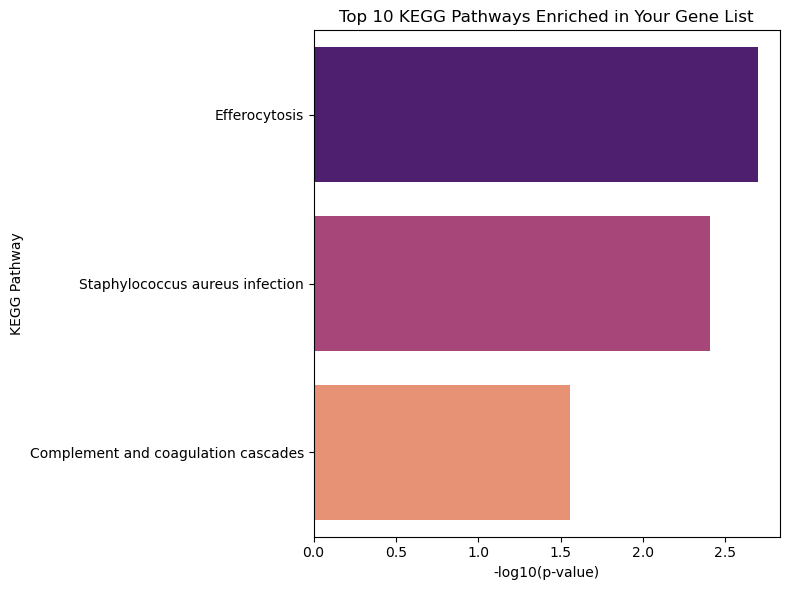

In [71]:
from gprofiler import GProfiler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# المحواة الخاصة بقائمة جيناتك المهمة
gene_list = filtered_common["Gene Name"].dropna().unique().tolist()

# تهيئة g:Profiler
gp = GProfiler(return_dataframe=True)

# الإثراء باستخدام KEGG
res = gp.profile(organism="hsapiens", query=gene_list, sources=["KEGG"])

# اختيار أفضل 10 مسارات من حيث أقل p-value
kegg = res[res["source"] == "KEGG"].nsmallest(10, "p_value")

# رسم barplot لتركيز المسارات الأكثر دلالة
plt.figure(figsize=(8, 6))
sns.barplot(x=-np.log10(kegg["p_value"]), y=kegg["name"], palette="magma")
plt.xlabel("-log10(p-value)")
plt.ylabel("KEGG Pathway")
plt.title("Top 10 KEGG Pathways Enriched in Your Gene List")
plt.tight_layout()
plt.show()


In [38]:
top_genes = df_counts["Total_Expression"].sort_values(ascending=False).head()
df_counts.loc[top_genes.index, ["Gene Name", "Total_Expression"]]


,Gene Name,Total_Expression
Gene ID,,
ENSG00000276168,RN7SL1,54350310
ENSG00000163220,S100A9,8777963
ENSG00000245532,NEAT1,8568992
ENSG00000075624,ACTB,8123529
ENSG00000119535,CSF3R,6072475


In [39]:
avg_per_sample = df_counts.iloc[:, 1:-1].mean()
avg_per_sample.sort_values(ascending=False).head()

ERR11658917    750.398254
ERR11658933    617.168299
ERR11658912    574.413854
ERR11658906    568.624135
ERR11658914    566.233867
dtype: float64

In [73]:
import numpy as np

avg_per_sample = df_counts.iloc[:, 1:-1].mean()
std_per_sample = df_counts.iloc[:, 1:-1].std()

threshold = avg_per_sample.mean() + std_per_sample.mean()
activity_level = avg_per_sample.apply(lambda x: "High" if x > threshold else "Low")

print("Samples classified by activity level:")
print(activity_level.value_counts())

print("\nHigh activity samples:")
print(activity_level[activity_level == "High"])



Samples classified by activity level:
Low     46
High     1
Name: count, dtype: int64

High activity samples:
Total_Expression    High
dtype: object


In [74]:
high_samples = activity_level[activity_level == "High"].index.tolist()
low_samples = activity_level[activity_level == "Low"].index.tolist()

high_expr = df_counts[high_samples].mean(axis=1)
low_expr = df_counts[low_samples].mean(axis=1)

diff_expr = high_expr - low_expr
top_diff_genes = diff_expr.abs().sort_values(ascending=False).head(20)

print(df_counts.loc[top_diff_genes.index, ["Gene Name"]])
print(top_diff_genes)


                Gene Name
Gene ID                  
ENSG00000276168    RN7SL1
ENSG00000163220    S100A9
ENSG00000245532     NEAT1
ENSG00000075624      ACTB
ENSG00000119535     CSF3R
ENSG00000137642     SORL1
ENSG00000105835     NAMPT
ENSG00000234745     HLA-B
ENSG00000166710       B2M
ENSG00000204592     HLA-E
ENSG00000143546    S100A8
ENSG00000265972     TXNIP
ENSG00000156508    EEF1A1
ENSG00000151726     ACSL1
ENSG00000112096       NaN
ENSG00000147454  SLC25A37
ENSG00000204525     HLA-C
ENSG00000081237     PTPRC
ENSG00000136167      LCP1
ENSG00000111913    RIPOR2
Gene ID
ENSG00000276168    5.316878e+07
ENSG00000163220    8.587138e+06
ENSG00000245532    8.382710e+06
ENSG00000075624    7.946931e+06
ENSG00000119535    5.940465e+06
ENSG00000137642    4.923460e+06
ENSG00000105835    4.737638e+06
ENSG00000234745    4.078565e+06
ENSG00000166710    3.851967e+06
ENSG00000204592    3.833909e+06
ENSG00000143546    3.635584e+06
ENSG00000265972    3.611746e+06
ENSG00000156508    3.551631e+06
ENSG

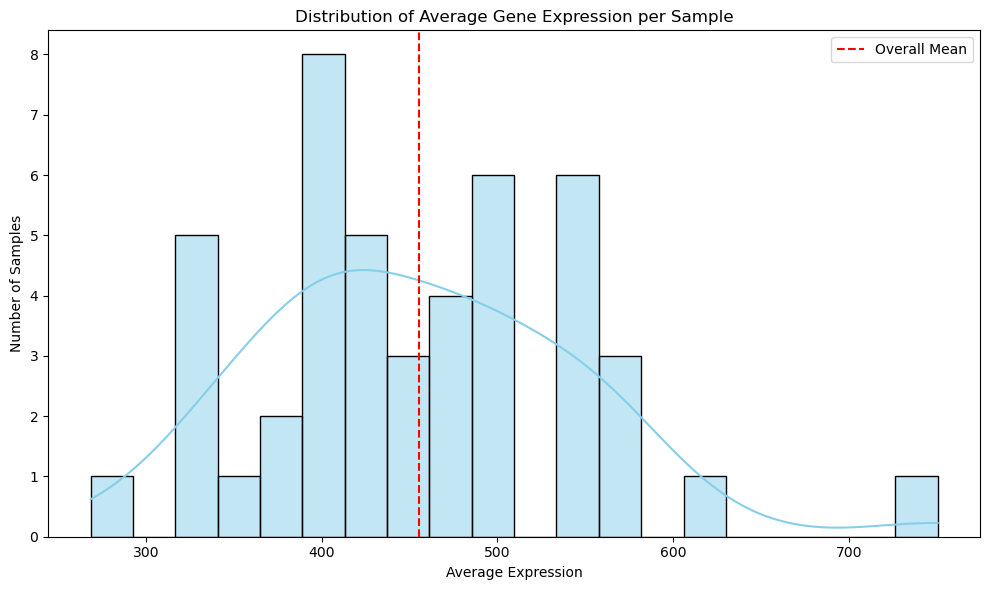

In [40]:
avg_per_sample = df_counts.iloc[:, 1:-1].mean()
plt.figure(figsize=(10, 6))
sns.histplot(avg_per_sample, bins=20, kde=True, color='skyblue')
plt.axvline(avg_per_sample.mean(), color='red', linestyle='--', label='Overall Mean')
plt.title("Distribution of Average Gene Expression per Sample")
plt.xlabel("Average Expression")
plt.ylabel("Number of Samples")
plt.legend()
plt.tight_layout()
plt.show()


In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

avg_per_sample = df_counts.iloc[:, 1:-1].mean()
overall_mean = avg_per_sample.mean()

high_activity_samples = avg_per_sample[avg_per_sample > overall_mean]
low_activity_samples = avg_per_sample[avg_per_sample <= overall_mean]

print("Number of high activity samples:", high_activity_samples.shape[0])
print("Number of low/normal activity samples:", low_activity_samples.shape[0])

print("Top 10 High Activity Samples:")
print(high_activity_samples.sort_values(ascending=False).head(10))


Number of high activity samples: 21
Number of low/normal activity samples: 25
Top 10 High Activity Samples:
ERR11658917    750.398254
ERR11658933    617.168299
ERR11658912    574.413854
ERR11658906    568.624135
ERR11658914    566.233867
ERR11658903    556.713207
ERR11658935    552.460297
ERR11658927    548.632056
ERR11658920    546.829922
ERR11658905    537.545862
dtype: float64


In [42]:
# Step 1: Extract sample names
high_samples = high_activity_samples.index.tolist()
low_samples = low_activity_samples.index.tolist()

# Step 2: Extract expression data (only gene counts, excluding 'Gene Name' and 'Total_Expression')
gene_expression = df_counts.iloc[:, 1:-1]

# Step 3: Compute average expression per gene in high and low activity groups
high_expr_avg = gene_expression[high_samples].mean(axis=1)
low_expr_avg = gene_expression[low_samples].mean(axis=1)

# Step 4: Calculate difference or fold change
expression_diff = high_expr_avg - low_expr_avg
expression_fc = (high_expr_avg + 1) / (low_expr_avg + 1)  # +1 to avoid division by zero

# Step 5: Create result DataFrame
gene_activity_diff = pd.DataFrame({
    "Gene Name": df_counts["Gene Name"],
    "High Group Avg": high_expr_avg,
    "Low Group Avg": low_expr_avg,
    "Difference": expression_diff,
    "Fold Change": expression_fc
})

# Step 6: Sort by difference or fold change
top_diff_genes = gene_activity_diff.sort_values(by="Difference", ascending=False).head(20)

# Show top 20 genes with highest expression difference
display(top_diff_genes)


,Gene Name,High Group Avg,Low Group Avg,Difference,Fold Change
Gene ID,,,,,
ENSG00000276168,RN7SL1,1.401502e+06,996750.44,404751.893333,1.406071
ENSG00000163220,S100A9,2.437033e+05,146407.72,97295.613333,1.664548
ENSG00000245532,NEAT1,2.269028e+05,152161.32,74741.489524,1.491196
ENSG00000075624,ACTB,2.100295e+05,148516.40,61513.076190,1.414181
ENSG00000119535,CSF3R,1.603152e+05,108234.20,52081.038095,1.481184
ENSG00000105835,NAMPT,1.290060e+05,85351.72,43654.280000,1.511457
ENSG00000143546,S100A8,1.023571e+05,62675.00,39682.142857,1.633131
ENSG00000166710,B2M,1.047394e+05,69521.56,35217.820952,1.506567
ENSG00000137642,SORL1,1.277060e+05,94041.80,33664.152381,1.357966


In [43]:
# Step 1: Prepare sample groups
high_samples = high_activity_samples.index.tolist()
low_samples = low_activity_samples.index.tolist()

# Step 2: Add numeric age column
df_wide["age_numeric"] = df_wide["age"].str.extract(r"(\d+)").astype(float)

# Step 3: Add activity level label
df_wide["activity_level"] = df_wide["Sample_ID"].apply(lambda x: "High" if x in high_samples else "Low")

# Step 4: Compare cohort distribution
cohort_counts = df_wide.groupby("activity_level")["cohort"].value_counts().unstack().fillna(0)
# Step 6: Show cohort distribution
print("Cohort Distribution by Activity Level:")
display(cohort_counts)

# Step 7: Identify individuals with multiple high-activity samples
high_individuals = df_wide[df_wide["activity_level"] == "High"]["individual"].value_counts()
print("Individuals with multiple high activity samples:")
print(high_individuals[high_individuals > 1])


Cohort Distribution by Activity Level:


cohort,PERFORM
activity_level,
High,21
Low,25


Individuals with multiple high activity samples:
Series([], Name: count, dtype: int64)


In [44]:
zero_genes = df_counts[df_counts.iloc[:, 1:-1].sum(axis=1) == 0]
print("Genes with zero expression:", len(zero_genes))

Genes with zero expression: 13173


In [76]:
df_counts_filtered = df_counts[df_counts.iloc[:, 1:-1].sum(axis=1) > 0].copy()

print("Number of genes after filtering zero-expression genes:", df_counts_filtered.shape[0])


Number of genes after filtering zero-expression genes: 48687


In [45]:
high_expr_genes = df_counts[df_counts["Total_Expression"] > df_counts["Total_Expression"].quantile(0.95)]
print("Highly expressed genes:", len(high_expr_genes))

Highly expressed genes: 3093


In [46]:
df_counts["Variance"] = df_counts.iloc[:, 1:-2].var(axis=1)
df_counts[["Gene Name", "Variance"]].sort_values(by="Variance", ascending=False).head()

,Gene Name,Variance
Gene ID,,
ENSG00000276168,RN7SL1,3.095773e+11
ENSG00000163220,S100A9,1.809016e+10
ENSG00000245532,NEAT1,1.585669e+10
ENSG00000143546,S100A8,5.915160e+09
ENSG00000119535,CSF3R,5.399488e+09


In [78]:
from sklearn.decomposition import PCA
gene_expression = df_counts.iloc[:, 1:-1].T  
pca = PCA(n_components=5) 
pca_result = pca.fit_transform(gene_expression)
explained_variance = pca.explained_variance_ratio_
print("Explained variance ratio per component:")
for i, var in enumerate(explained_variance, 1):
    print(f"PC{i}: {var:.4f}")

Explained variance ratio per component:
PC1: 0.9979
PC2: 0.0013
PC3: 0.0003
PC4: 0.0001
PC5: 0.0001


In [81]:
print(activity_df.columns)
print(activity_df.head())


Index(['Sample_ID', 'avg_expression', 'activity_level'], dtype='object')
     Sample_ID  avg_expression activity_level
0  ERR11658905      537.545862            Low
1  ERR11658920      546.829922            Low
2  ERR11658906      568.624135            Low
3  ERR11658917      750.398254            Low
4  ERR11658912      574.413854            Low


In [83]:
df_wide_with_activity = df_wide.merge(activity_df[['Sample_ID', 'activity_level']], on='Sample_ID', how='left')


In [87]:
print(df_counts.index[:10])


Index(['ENSG00000000003', 'ENSG00000000005', 'ENSG00000000419',
       'ENSG00000000457', 'ENSG00000000460', 'ENSG00000000938',
       'ENSG00000000971', 'ENSG00000001036', 'ENSG00000001084',
       'ENSG00000001167'],
      dtype='object', name='Gene ID')


In [90]:
import statsmodels.formula.api as smf
gene_id = "ENSG00000000003"

if gene_id not in df_counts.index:
    print(f"gene {gene_id} غير موجود في df_counts.")
else:
    valid_samples = [s for s in df_wide["Sample_ID"] if s in df_counts.columns]
    data = df_wide[df_wide["Sample_ID"].isin(valid_samples)].copy()
    expression = df_counts.loc[gene_id, valid_samples].astype(float)
    expression = expression.reindex(data["Sample_ID"].values)
    data["expression"] = expression.values
    data["cohort"] = data["cohort"].astype("category")
    model = smf.ols("expression ~ cohort + age_numeric", data=data).fit()
    print(model.summary())


                            OLS Regression Results                            
Dep. Variable:             expression   R-squared:                       0.057
Model:                            OLS   Adj. R-squared:                  0.035
Method:                 Least Squares   F-statistic:                     2.650
Date:                Tue, 05 Aug 2025   Prob (F-statistic):              0.111
Time:                        21:34:45   Log-Likelihood:                -145.62
No. Observations:                  46   AIC:                             295.2
Df Residuals:                      44   BIC:                             298.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       9.0793      1.876      4.840      

In [96]:
print(df_genes.columns)

Index(['Gene ID', 'Gene Name', 'g3_g1.p-value', 'g3_g1.log2foldchange',
       'g3_g2.p-value', 'g3_g2.log2foldchange', 'g3_g1_class', 'g3_g2_class'],
      dtype='object')


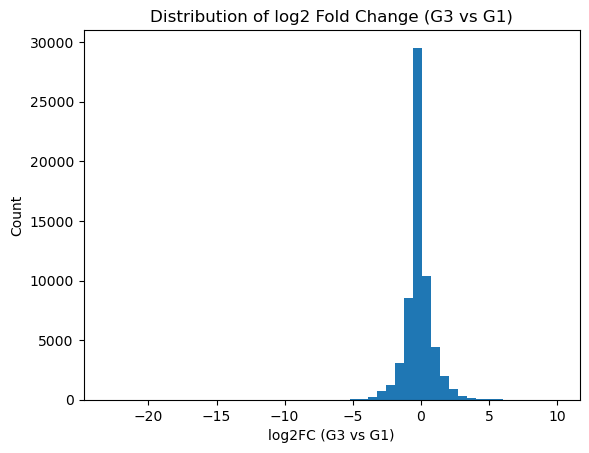

In [97]:
plt.hist(df_genes['g3_g1.log2foldchange'], bins=50)
plt.title("Distribution of log2 Fold Change (G3 vs G1)")
plt.xlabel("log2FC (G3 vs G1)")
plt.ylabel("Count")
plt.show()

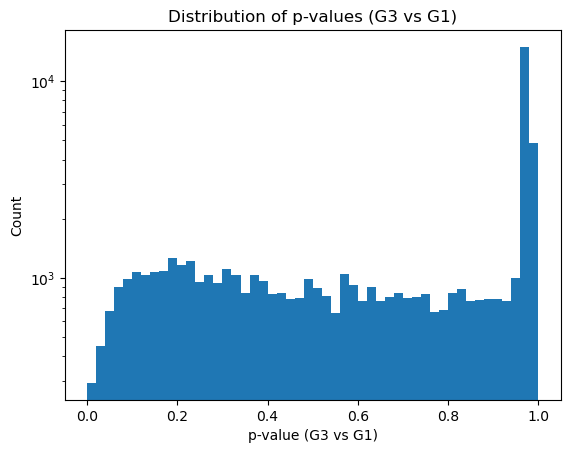

In [98]:
plt.hist(df_genes['g3_g1.p-value'].dropna(), bins=50)
plt.title("Distribution of p-values (G3 vs G1)")
plt.xlabel("p-value (G3 vs G1)")
plt.ylabel("Count")
plt.yscale("log")  # log scale لأن البيانات skewed
plt.show()

In [99]:

def classify_gene(row):
    if row['g3_g1.p-value'] < 0.05:
        if row['g3_g1.log2foldchange'] > 1:
            return 'Upregulated'
        elif row['g3_g1.log2foldchange'] < -1:
            return 'Downregulated'
    return 'Normal'

df_genes['g3_g1_class'] = df_genes.apply(classify_gene, axis=1)
print(df_genes['g3_g1_class'].value_counts())

g3_g1_class
Normal           60909
Upregulated        676
Downregulated      275
Name: count, dtype: int64


In [100]:
percentages = df_genes['g3_g1_class'].value_counts(normalize=True) * 100
print(percentages)

g3_g1_class
Normal           98.462658
Upregulated       1.092790
Downregulated     0.444552
Name: proportion, dtype: float64


In [115]:
df_counts = pd.read_csv("E-CURD-149-raw-counts.tsv", sep="\t", index_col=0)
df_genes = pd.read_csv("E-CURD-149-analytics.tsv", sep="\t")
df_sdrf = pd.read_csv("E-CURD-149.condensed-sdrf.tsv", sep="\t", on_bad_lines='skip', header=None)
df_sdrf.columns = ["Experiment", "Unused", "Sample_ID", "Type", "Attribute", "Value"]
df_sdrf = df_sdrf[df_sdrf["Type"] == "characteristic"]
df_wide = df_sdrf.pivot_table(index="Sample_ID", columns="Attribute", values="Value", aggfunc='first').reset_index()
df_counts_reset = df_counts.reset_index()
gene_names = df_counts_reset[['Gene ID', 'Gene Name']]
df_counts_only = df_counts_reset.drop(columns=['Gene Name']).set_index('Gene ID')
df_genes = df_genes.merge(gene_names, on='Gene ID', how='left')
df_full = df_genes.merge(df_counts_only, left_on='Gene ID', right_index=True, how='left')

In [116]:
print("Number of unique genes:", df_full["Gene ID"].nunique())
print("Number of samples:", df_counts_only.shape[1])
print("Number of columns:", df_full.shape[1])
df_full.head()

Number of unique genes: 61860
Number of samples: 46
Number of columns: 53


,Gene ID,Gene Name_x,g3_g1.p-value,g3_g1.log2foldchange,g3_g2.p-value,g3_g2.log2foldchange,Gene Name_y,ERR11658905,ERR11658920,ERR11658906,...,ERR11658919,ERR11658918,ERR11658902,ERR11658900,ERR11658899,ERR11658901,ERR11658916,ERR11658915,ERR11658897,ERR11658934
0,ENSG00000000003,TSPAN6,0.635570,-0.7,0.055791,-1.3,TSPAN6,0,10,16,...,4,2,9,1,5,6,0,0,6,1
1,ENSG00000000005,TNMD,NaN,-2.1,NaN,-0.7,TNMD,1,2,2,...,0,0,0,0,0,0,0,0,0,0
2,ENSG00000000419,DPM1,0.365973,0.3,0.164996,0.2,DPM1,854,853,1020,...,753,459,613,576,575,532,410,430,660,1056
3,ENSG00000000457,SCYL3,0.609381,0.2,0.092423,0.3,SCYL3,1179,694,1127,...,740,531,710,591,605,508,435,449,638,961
4,ENSG00000000460,FIRRM,0.973755,0.0,0.324863,0.2,FIRRM,365,302,375,...,263,207,264,181,202,145,110,161,229,328


In [117]:
missing = df_full.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing)

Columns with missing values:
g3_g1.p-value    31826
g3_g2.p-value    26257
Gene Name_x      19583
Gene Name_y      19583
dtype: int64


In [134]:
# 1. All genes without filtering
df_all_genes = df_full.copy()

# 2. Genes that have names (i.e., Gene Name is not missing)
df_named_only = df_full[df_full['Gene Name_x'].notna()].copy()

# 3. Genes with valid statistical values (non-missing p-values for both comparisons)
df_valid_stats = df_full[df_full['g3_g1.p-value'].notna() & df_full['g3_g2.p-value'].notna()].copy()

In [130]:
print(df_full.columns)


Index(['Gene ID', 'Gene Name_x', 'g3_g1.p-value', 'g3_g1.log2foldchange',
       'g3_g2.p-value', 'g3_g2.log2foldchange', 'Gene Name_y', 'ERR11658905',
       'ERR11658920', 'ERR11658906', 'ERR11658917', 'ERR11658912',
       'ERR11658914', 'ERR11658913', 'ERR11658911', 'ERR11658935',
       'ERR11658933', 'ERR11658937', 'ERR11658910', 'ERR11658909',
       'ERR11658908', 'ERR11658925', 'ERR11658940', 'ERR11658941',
       'ERR11658942', 'ERR11658907', 'ERR11658927', 'ERR11658929',
       'ERR11658926', 'ERR11658930', 'ERR11658931', 'ERR11658932',
       'ERR11658898', 'ERR11658904', 'ERR11658903', 'ERR11658939',
       'ERR11658938', 'ERR11658936', 'ERR11658928', 'ERR11658923',
       'ERR11658922', 'ERR11658924', 'ERR11658921', 'ERR11658919',
       'ERR11658918', 'ERR11658902', 'ERR11658900', 'ERR11658899',
       'ERR11658901', 'ERR11658916', 'ERR11658915', 'ERR11658897',
       'ERR11658934', 'g3_g1_class'],
      dtype='object')


In [121]:
significant_genes = df_full[
    (df_full["g3_g1.p-value"] < 0.05) &
    (abs(df_full["g3_g1.log2foldchange"]) > 1)]
print(" Number of significant genes:", significant_genes.shape[0])

 Number of significant genes: 721


In [122]:
df_full['g3_g1_class'] = df_full.apply(lambda row: 
    'Upregulated' if pd.notna(row['g3_g1.p-value']) and row['g3_g1.p-value'] < 0.05 and row['g3_g1.log2foldchange'] > 1 else
    'Downregulated' if pd.notna(row['g3_g1.p-value']) and row['g3_g1.p-value'] < 0.05 and row['g3_g1.log2foldchange'] < -1 else
    'Normal', axis=1)

In [123]:
df_significant = df_full[df_full['g3_g1.p-value'] < 0.05].copy()

In [124]:
df_significant['g3_g1_class'] = df_significant.apply(lambda row: 
    'Upregulated' if row['g3_g1.log2foldchange'] > 1 else
    'Downregulated' if row['g3_g1.log2foldchange'] < -1 else
    'Normal', axis=1)

In [125]:
top_up = df_significant[df_significant['g3_g1_class'] == 'Upregulated']\
    .sort_values(by='g3_g1.log2foldchange', ascending=False).head(10)

top_down = df_significant[df_significant['g3_g1_class'] == 'Downregulated']\
    .sort_values(by='g3_g1.log2foldchange').head(10)

print("Top Upregulated Genes:")
print(top_up[['Gene ID', 'Gene Name_x', 'g3_g1.log2foldchange']])

print("\nTop Downregulated Genes:")
print(top_down[['Gene ID', 'Gene Name_x', 'g3_g1.log2foldchange']])

Top Upregulated Genes:
               Gene ID Gene Name_x  g3_g1.log2foldchange
4774   ENSG00000118113        MMP8                  10.0
7553   ENSG00000137869     CYP19A1                   9.3
2707   ENSG00000102837       OLFM4                   9.1
11102  ENSG00000163710     PCOLCE2                   9.0
27284  ENSG00000227292         NaN                   8.2
20030  ENSG00000204936       CD177                   7.8
27600  ENSG00000227770     RPL7P12                   7.4
41488  ENSG00000253931         NaN                   7.2
3002   ENSG00000104918        RETN                   7.1
49942  ENSG00000269228   RPS27AP19                   7.1

Top Downregulated Genes:
               Gene ID Gene Name_x  g3_g1.log2foldchange
47235  ENSG00000263503  MAPK8IP1P2                 -23.1
43059  ENSG00000255998   LINC02824                  -6.5
49234  ENSG00000267453     CLEC4OP                  -5.8
46662  ENSG00000261628         NaN                  -5.8
2036   ENSG00000095627       TDRD1     

In [126]:
print("Missing Gene Names:", df_full['Gene Name_x'].isna().sum())
print("Missing g3_g1.p-value:", df_full['g3_g1.p-value'].isna().sum())

Missing Gene Names: 19583
Missing g3_g1.p-value: 31826


In [127]:
df_clean = df_full[
    df_full['Gene Name_x'].notna() &
    df_full['g3_g1.p-value'].notna() &
    df_full['g3_g2.p-value'].notna()
]

In [128]:
def classify_lfc(lfc):
    if lfc > 1:
        return 'Upregulated'
    elif lfc < -1:
        return 'Downregulated'
    else:
        return 'No Change'

df_significant['g3_g1_class'] = df_significant['g3_g1.log2foldchange'].apply(classify_lfc)
df_significant['g3_g2_class'] = df_significant['g3_g2.log2foldchange'].apply(classify_lfc)

In [129]:
print("Clean genes:", df_clean.shape[0])
print("Significant genes:", df_significant.shape[0])
print("Upregulated (G3 vs G1):", (df_significant['g3_g1_class'] == 'Upregulated').sum())
print("Downregulated (G3 vs G1):", (df_significant['g3_g1_class'] == 'Downregulated').sum())

Clean genes: 22817
Significant genes: 847
Upregulated (G3 vs G1): 532
Downregulated (G3 vs G1): 189
